In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

In [2]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [3]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

import functions_case as il
import importlib

import functions_tertiary as il3
import comprehensive_functions as comp

In [6]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv")

# Define features and target
X = df.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # Features
y = df['age']  # Target: age

# define models
DecisionTreeReg = DecisionTreeRegressor(max_depth = 20, 
                                 max_features=150,
                                 random_state=949
                                 )

In [7]:
models = [DecisionTreeReg]

In [8]:
J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000

In [9]:
mp_ensemble = comp.mp_ensemble(X, y, n_ratio, m_ratio, B, models, adjust_col=None)

In [10]:
np.savez("pdp_ensemble_rf.npz", ensemble = mp_ensemble['ensemble'], predictions=mp_ensemble['predictions'], obs=mp_ensemble['mp_observations'], feats=mp_ensemble['mp_features'])

In [4]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Separate features and target
X = df.drop(columns=['phase'])
y = le.fit_transform(df['phase'])
adjust_col = X.columns.get_loc("Metadata_well")

feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
feature_triplets = list(itertools.combinations(range(X.shape[1]), 3))

In [5]:
DecisionTreeClass = DecisionTreeClassifier(max_depth = 50, 
                                 max_features=10,
                                 random_state=949
                                 )

In [6]:
xgbclass = GradientBoostingClassifier(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.1, # hyperparameters from XGB model
        max_depth=7,
        random_state=949
    )

In [7]:
# Define RBF-kernel SVM
svmclass = svm_model = SVC(
    kernel='rbf',
    C=1.0,              
    gamma='scale',
    probability=True,
    random_state=949
)

In [8]:
J1 = 0
J2 = 1
m_ratio = 0.2
n_ratio = 0.2
B = 10
models = [DecisionTreeClass, xgbclass, svmclass]
adjust_col = adjust_col

In [9]:
mp_ensemble = comp.mp_ensemble(X, y, n_ratio, m_ratio, B, models, adjust_col=None)

In [10]:
feature_groups = comp.make_feature_groups(X, order=3, include_col=None, subset=None)

In [11]:
mp_results = comp.featureInteractions(X, y, mp_ensemble, feature_groups, order=3, type = "classification", bonferroni = True)

In [15]:
mp_features = [mp_results[(i, j, k)]['features'] for (i,j, k) in feature_groups]
mp_scores = [mp_results[(i, j, k)]['iloco'] for (i,j, k) in feature_groups]
mp_ci = [mp_results[(i, j, k)]["ci"] for (i, j, k) in feature_groups]

In [16]:
data = {'feature': mp_features, 'scores': mp_scores, 'ci': mp_ci }
df = pd.DataFrame(data)

In [17]:
top_20 = df.nlargest(10, "scores")

/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_26966/3419943142.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


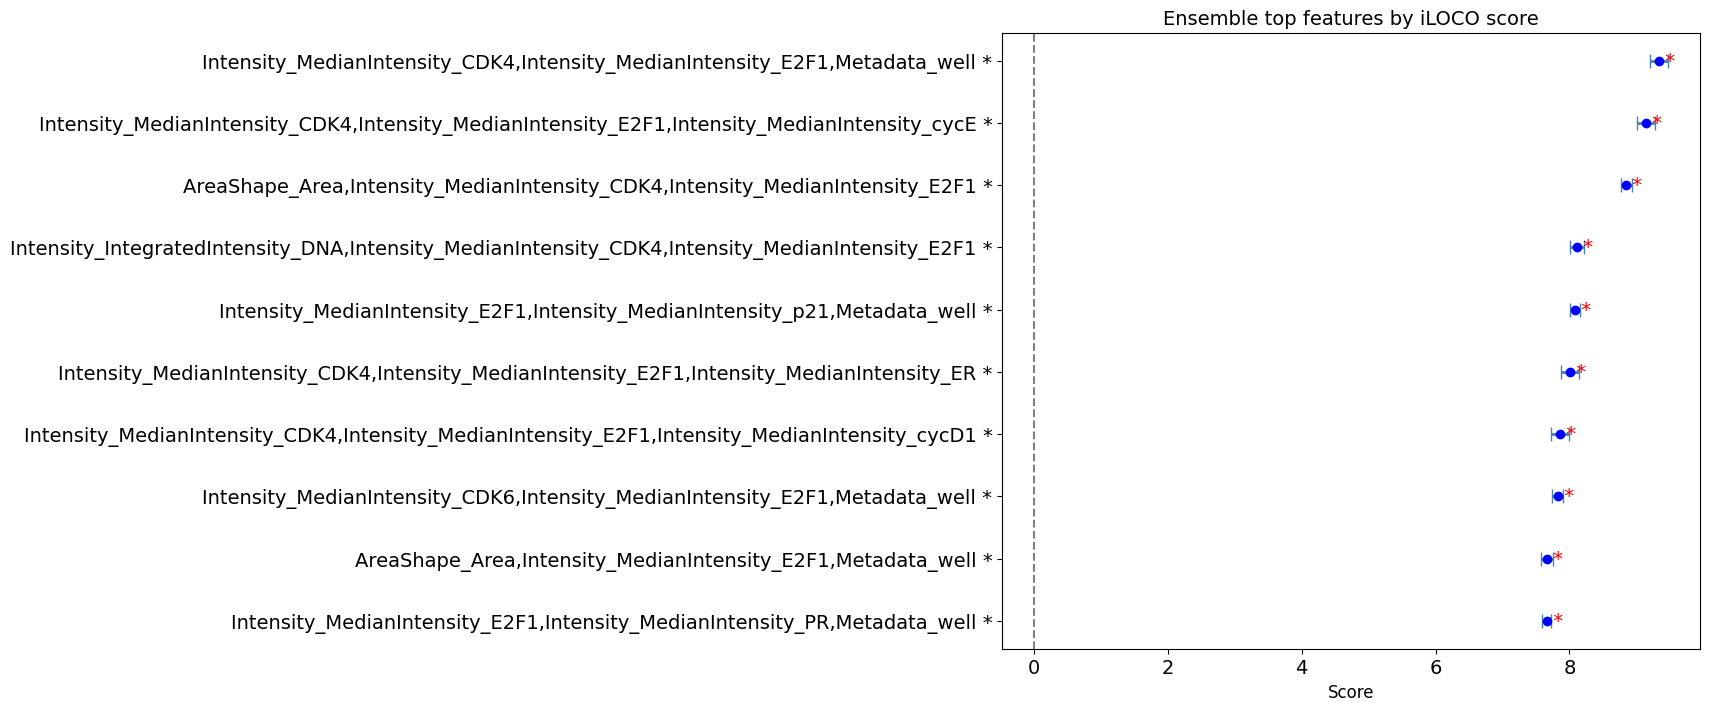

In [18]:
# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Ensemble top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()